# Emulator Accuracy
---
Evaluates the trained emulator on the 20% test set held out during training.

Computes:
- Mean Absolute Percentage Error (%)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- Empirical Coverage
- Standardized residuals (z)
- Reduced Chi-Square, held-out (no parameters were fit, so DOF = number of points)
- Reduced Chi-Square, training set (DOF = number of points - fitted parameters)

Produces five figures:
1. Mean Percent Error Per Bin
2. True vs Predicted Rescaled kSZ Angular Power Spectrum ($D_\ell$)
3. One-to-One Plot
4. Violin Plots of True vs Predicted Distributions
5. Many Held-Out Spectra Plot

More information about the package can be found here: [Documentation](https://reionemu.org/)

## Imports

In [1]:
import sys
import json

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from reionemu import (
    load_training_arrays,
    MCDropoutEmulator,
    Normalizer,
    predict_mc,
    make_dataloaders,
)

## Paths, Configs, and Constants

In [2]:
# Paths
from config import H5_PATH, MODEL_PATH, NORM_PATH, FIG_DIR, EXPERIMENT_NAME, make_dirs
from config import HELDOUT_INDICES_PATH, HELDOUT_METRICS_PATH, HELDOUT_PREDICTIONS_PATH
from config import SPLIT, dlcfg

# Constants
from config import SEED, N_MC_PLOT, device

make_dirs()

## Seeding

In [3]:
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Python:\t\t{sys.version.split()[0]}")
print("-" * 30)
print(f"NumPy:\t\t{np.__version__}")
print(f"PyTorch:\t{torch.__version__}")
print("-" * 30)
print(f"Global Seed:\t{SEED}")

Python:		3.13.1
------------------------------
NumPy:		2.5.2
PyTorch:	2.13.0
------------------------------
Global Seed:	42


## Load Trained Model

In [4]:
ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)

model = MCDropoutEmulator(**ckpt["model_config"])
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

norms = {
    "X": Normalizer(
        mean=np.load(NORM_PATH / "X_mean.npy"),
        std=np.load(NORM_PATH / "X_std.npy"),
    ),
    "Y": None,
}

heldout_indices = np.load(HELDOUT_INDICES_PATH)

print(f"Model:\n{MODEL_PATH}")
print(f"Architecture:\t{ckpt['model_config']}")
print(f"normalize_X:\t{ckpt['normalize_X']}")
print(f"normalize_Y:\t{ckpt['normalize_Y']}")

Model:
/Users/robertxpearce/Desktop/Research/LEADS Lab/reionemu/reionemu-pasa-2026/checkpoints/pearce_2026_reionemu_mc_dropout/mc_dropout_n_mc_201_epochs_1000_early_stop_150/model.pt
Architecture:	{'input_dim': 4, 'output_dim': 5, 'hidden_dim': 20, 'num_hidden_layers': 2, 'activation': 'relu', 'dropout_rate': 0.1}
normalize_X:	True
normalize_Y:	False


# Error and Uncertainty Metrics
---

## Separate Held-Out Test Set

In [5]:
X, Y, ell = load_training_arrays(H5_PATH)

X_heldout = X[heldout_indices]
Y_heldout = Y[heldout_indices]

print(f"Held-out Samples:\t\t{len(heldout_indices)}")
print(heldout_indices)

Held-out Samples:		200
[560 481 499 323  93 843 877 763 389 397 564  32 386 364 667 453 440 640
 633 227 369 642 416 452  81 827 820 863 370 311 450  52 912 342 540 267
 721 106 122 396 992 533 730 384 105 266 347 190 864 850  39 339 188 403
 525 189 812  87 732 483   5 597 699 953 442 893 861 385 332 790 359 590
 504 962 375 114 170 851 123 301 615 602 711 786 918 508 718 599 221 654
 111 475 484 329 279 277 349 956 187  65 974 611 583 948  69 410 689 637
 177 736 982 117 586 372  10 628 927 669  63 735 500   1  42 634 529 167
 809 821  76 313 296 502 490 720 837 543 641 939 617 290 779 910 212 555
 967 672 317  57 791 535 932 272  15 432 503 828 621 137 702 287 451 528
 300 752 622 943 195  34 286 314 970 547 333 182  49 518 102 687 651  41
 553 366 534 275 675 832 303 113 749 908 437 491 526 141 706 548 609 961
 973 648]


## Make Predictions

In [6]:
torch.manual_seed(SEED)

pred_mean, pred_std, samples_dl, samples_log = predict_mc(
    X_heldout,
    model,
    norms["X"].mean,
    norms["X"].std,
    normalize_X=True,
    n_mc_samples=N_MC_PLOT,
    device=device,
)

true = np.exp(Y_heldout)

# Aliased under held-out-specific names
heldout_pred_mean = pred_mean
heldout_pred_std = pred_std

## Mean Absolute Percentage Error (%) | Mean Squared Error (MSE) | Root Mean Squared Error (RMSE) | Mean Absolute Error (MAE)

In [7]:
absolute_relative_error = np.abs((pred_mean - true) / true)
mean_absolute_relative_error = np.mean(np.abs((pred_mean - true) / true))
percent_err = mean_absolute_relative_error * 100

test_mse = np.mean((pred_mean - true) ** 2)
test_rmse = np.sqrt(test_mse)
test_mae = np.mean(np.abs(pred_mean - true))

print(f"Mean Absolute Percentage Error (MAPE):\t{percent_err:.2f}")
print(f"Mean Squared Error (MSE):\t\t\t\t{test_mse:.4f}")
print(f"Root Mean Squared Error (RMSE):\t\t\t{test_rmse:.4f}")
print(f"Mean Absolute Error (MAE):\t\t\t\t{test_mae:.4f}")

Mean Absolute Percentage Error (MAPE):	5.12
Mean Squared Error (MSE):				0.0046
Root Mean Squared Error (RMSE):			0.0678
Mean Absolute Error (MAE):				0.0470


## MC-Dropout Predictive Uncertainty Coverage

In [8]:
# Standardized residuals
z_signed = (pred_mean - true) / pred_std
z_score = np.abs(pred_mean - true) / pred_std

# Coverage
phy_coverage_1sigma = np.mean(np.abs(pred_mean - true) <= pred_std) * 100
phy_coverage_2sigma = np.mean(np.abs(pred_mean - true) <= 2.0 * pred_std) * 100
phy_coverage_3sigma = np.mean(np.abs(pred_mean - true) <= 3.0 * pred_std) * 100

# Reduced chi-square
chi_squared = (z_score ** 2).sum()
dof = z_score.size
reduced_chi_squared = (z_score ** 2).mean()

print("1-Sigma Coverage:\t", phy_coverage_1sigma)
print("2-Sigma Coverage:\t", phy_coverage_2sigma)
print("3-Sigma Coverage:\t", phy_coverage_3sigma)
print()
print(f"Chi-Squared:\t\t\t{chi_squared:.2f}")
print(f"DOF:\t\t\t\t\t{dof}")
print(f"Reduced Chi-Squared:\t{reduced_chi_squared:.3f}")
print()
print(f"Median |z|:\t\t{np.median(z_score):.3f}")
print(f"Max |z|:\t\t{np.max(z_score):.2f}")
print(f"Mean Signed z:\t{np.mean(z_signed):.3f}")

1-Sigma Coverage:	 67.10000000000001
2-Sigma Coverage:	 89.7
3-Sigma Coverage:	 97.1

Chi-Squared:			1500.31
DOF:					1000
Reduced Chi-Squared:	1.500

Median |z|:		0.629
Max |z|:		5.70
Mean Signed z:	-0.359


## Chi-Squared on the Training Set

In [9]:
loaders, _, _ = make_dataloaders(h5_path=H5_PATH, split=SPLIT, config=dlcfg)
train_indices = np.asarray(loaders["train"].dataset.indices, dtype=int)

rebuilt_heldout = np.asarray(loaders["test"].dataset.indices, dtype=int)
assert np.array_equal(rebuilt_heldout, heldout_indices), "Rebuilt split does not match the held-out indices saved by 02"
assert len(np.intersect1d(train_indices, heldout_indices)) == 0, "Training indices overlap the held-out set"
print(f"Split verified against 02: train={len(train_indices)}, heldout={len(heldout_indices)}\n")

X_train = X[train_indices]
Y_train = Y[train_indices]

torch.manual_seed(SEED)

train_pred_mean, train_pred_std, _, _ = predict_mc(
    X_train,
    model,
    norms["X"].mean,
    norms["X"].std,
    normalize_X=True,
    n_mc_samples=N_MC_PLOT,
    device=device,
)

true_train = np.exp(Y_train)

z_train = (train_pred_mean - true_train) / train_pred_std
chi_squared_train = (z_train ** 2).sum()

n_parameters = sum(p.numel() for p in model.parameters())
n_points_train = z_train.size
dof_train = n_points_train - n_parameters
reduced_chi_squared_train = chi_squared_train / dof_train

print(f"Training Simulations:\t\t{len(train_indices)}")
print(f"Training Points:\t\t\t{n_points_train}")
print(f"Model Parameters:\t\t\t{n_parameters}")
print(f"DOF (points - parameters):\t{dof_train}")
print()
print(f"Chi-Squared:\t\t\t{chi_squared_train:.2f}")
print(f"Reduced Chi-Squared:\t{reduced_chi_squared_train:.3f}")

Split verified against 02: train=700, heldout=200

Training Simulations:		700
Training Points:			3500
Model Parameters:			625
DOF (points - parameters):	2875

Chi-Squared:			3787.29
Reduced Chi-Squared:	1.317


## Best-Case Simulation

In [10]:
mean_error_per_sim = np.mean(absolute_relative_error, axis=1)

best_sim_testset_idx = np.argmin(mean_error_per_sim)
best_sim_global_idx = heldout_indices[best_sim_testset_idx]

print(f"Global Dataset Index: {best_sim_global_idx} \t Test-Set Index: {best_sim_testset_idx}")
print(f"Mean Absolute Relative Error: \t {(mean_error_per_sim[best_sim_testset_idx] * 100):.2f}%")

Global Dataset Index: 277 	 Test-Set Index: 95
Mean Absolute Relative Error: 	 0.51%


## Worst-Case Simulation

In [11]:
worst_sim_testset_idx = np.argmax(mean_error_per_sim)
worst_sim_global_idx = heldout_indices[worst_sim_testset_idx]

print(f"Global Dataset Index: {worst_sim_global_idx} \t Test-Set Index: {worst_sim_testset_idx}")
print(f"Mean Absolute Relative Error: \t {(mean_error_per_sim[worst_sim_testset_idx] * 100):.2f}%")

Global Dataset Index: 850 	 Test-Set Index: 49
Mean Absolute Relative Error: 	 18.41%


## Mean Percent Error Per Bin

Mean % Error Per ell Bin:
ell = 2033: 5.866%
ell = 4093: 4.996%
ell = 6153: 4.826%
ell = 8213: 4.930%
ell = 10273: 4.972%



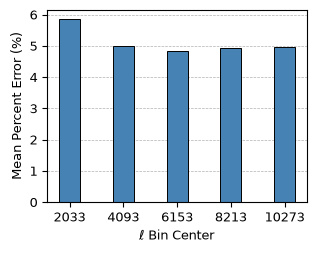

In [12]:
bin_percent_err = np.mean(absolute_relative_error, axis=0) * 100

print("Mean % Error Per ell Bin:")
ell_centers = np.asarray(ell).copy()
for ell_center, err in zip(ell_centers, bin_percent_err):
    print(f"ell = {ell_center:.0f}: {err:.3f}%")
print()

fig, ax = plt.subplots() 
ax.bar(
    ell_centers, 
    bin_percent_err, 
    width=800, 
    color='steelblue', 
    alpha=1, 
    edgecolor="black", 
    linewidth=0.7
)
ax.set_xlabel(r"$\ell$ Bin Center")
ax.set_xticks(ell_centers)
ax.set_xticklabels(ax.set_xticklabels([f"{e:.0f}" for e in ell_centers]))
ax.set_ylabel("Mean Percent Error (%)")
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=1)
fig.savefig(FIG_DIR / f'mean_percent_error_per_ell_{EXPERIMENT_NAME}.pdf', format='pdf', bbox_inches="tight")
plt.show()

## True vs Predicted Rescaled kSZ Angular Power Spectrum ($D_\ell$)

In [13]:
BEST_SIM = best_sim_global_idx
WORST_SIM = worst_sim_global_idx

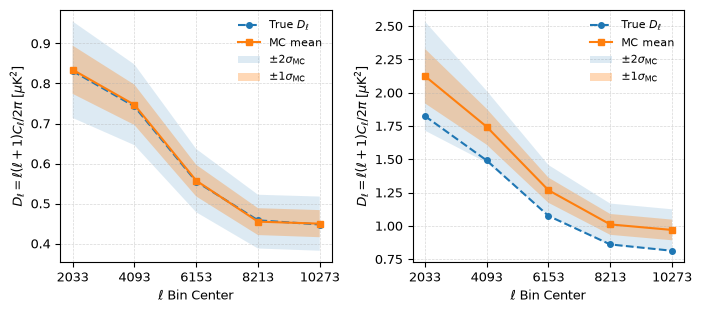

In [14]:
def plot_best_and_worst(best_idx, worst_idx):
    fig, ax = plt.subplots(1, 2, figsize=(7.1, 3.2))

    sim_indices = [best_idx, worst_idx]

    for i, sim_idx in enumerate(sim_indices):
        # Fetch data for this specific simulation
        params = X[sim_idx]
        true_dl = np.exp(Y[sim_idx])
        
        torch.manual_seed(SEED)
        
        pred_dl, pred_std, samples_dl, samples_log = predict_mc(
            params,
            model,
            norms["X"].mean,
            norms["X"].std,
            normalize_X=True,
            n_mc_samples=N_MC_PLOT,
        )

        # Plot True Data
        ax[i].plot(
            ell,
            true_dl,
            marker="o",
            linestyle="--",
            markersize=4,
            label=r"True $D_\ell$",
        )

        # Plot MC Mean
        ax[i].plot(
            ell,
            pred_dl,
            marker="s",
            linestyle="-",
            markersize=4,
            label=r"MC mean",
        )

        # Plot 2-Sigma Fill
        ax[i].fill_between(
            ell,
            pred_dl - 2.0 * pred_std,
            pred_dl + 2.0 * pred_std,
            alpha=0.15,
            label=r"$\pm 2\sigma_{\rm MC}$",
        )

        # Plot 1-Sigma Fill
        ax[i].fill_between(
            ell,
            pred_dl - pred_std,
            pred_dl + pred_std,
            alpha=0.30,
            label=r"$\pm 1\sigma_{\rm MC}$",
        )

        ax[i].set_xlabel(r"$\ell$ Bin Center")
        ax[i].grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
        ax[i].legend(frameon=False, fontsize=8)

    ax[0].set_ylabel(r"$D_\ell = \ell(\ell + 1)C_\ell / 2\pi$ [$\mu \mathrm{K}^2$]")
    ax[1].set_ylabel(r"$D_\ell = \ell(\ell + 1)C_\ell / 2\pi$ [$\mu \mathrm{K}^2$]")

    ax[0].set_xticks(ell_centers)
    ax[0].set_xticklabels([f"{e:.0f}" for e in ell_centers])
    
    ax[1].set_xticks(ell_centers)
    ax[1].set_xticklabels([f"{e:.0f}" for e in ell_centers])

    plt.tight_layout()

    fig.savefig(FIG_DIR / f"mc_dropout_best_worst_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
    plt.show()


plot_best_and_worst(BEST_SIM, WORST_SIM)

## One-to-One Plot

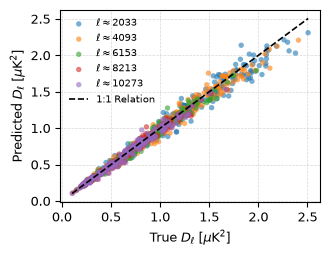

(200, 5) (200, 5)


In [15]:
fig, ax = plt.subplots()

for b, ell_center in enumerate(ell):
    ax.scatter(
        true[:, b],
        pred_mean[:, b],
        s=15,
        alpha=0.6,
        edgecolors='none',
        label=rf"$\ell \approx {ell_center:.0f}$",
        zorder=2
    )

min_val = min(true.min(), pred_mean.min())
max_val = max(true.max(), pred_mean.max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="black",
    linewidth=1.2,
    label="1:1 Relation",
    zorder=3
)

ax.set_xlabel(r"True $D_\ell$ [$\mu \mathrm{K}^2$]")
ax.set_ylabel(r"Predicted $D_\ell$ [$\mu \mathrm{K}^2$]")

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

ax.legend(frameon=False, fontsize=7)

fig.savefig(FIG_DIR / f"true_vs_predicted_all_bins_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

print(true.shape, pred_mean.shape)

## Violin Plots of True vs Predicted Distributions

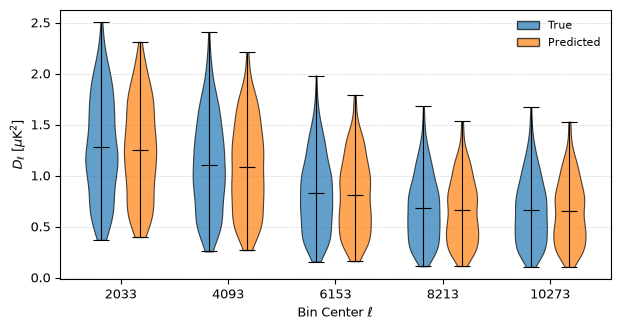

In [16]:
fig, ax = plt.subplots(figsize=(7.1, 3.5))

positions = np.arange(len(ell_centers))
offset = 0.18

true_parts = ax.violinplot(
    [true[:, b] for b in range(len(ell_centers))],
    positions=positions - offset,
    widths=0.3,
    showmeans=True,
    showextrema=True,
)

pred_parts = ax.violinplot(
    [pred_mean[:, b] for b in range(len(ell_centers))],
    positions=positions + offset,
    widths=0.3,
    showmeans=True,
    showextrema=True,
)

for pc in true_parts['bodies']:
    pc.set_facecolor('tab:blue')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7) 
    pc.set_linewidth(0.8)

for partname in ('cbars', 'cmins', 'cmaxes', 'cmeans'):
    true_parts[partname].set_edgecolor('black')
    true_parts[partname].set_linewidth(0.8)

for pc in pred_parts['bodies']:
    pc.set_facecolor('tab:orange')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)
    pc.set_linewidth(0.8)

for partname in ('cbars', 'cmins', 'cmaxes', 'cmeans'):
    pred_parts[partname].set_edgecolor('black')
    pred_parts[partname].set_linewidth(0.8)

ax.set_xticks(positions)
ax.set_xticklabels([f"{e:.0f}" for e in ell_centers])
ax.set_xlabel(r"Bin Center $\ell$")
ax.set_ylabel(r"$D_\ell$ [$\mu \mathrm{K}^2$]")

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

true_patch = mpatches.Patch(facecolor='tab:blue', edgecolor='black', alpha=0.7, label='True')
pred_patch = mpatches.Patch(facecolor='tab:orange', edgecolor='black', alpha=0.7, label='Predicted')
ax.legend(handles=[true_patch, pred_patch], frameon=False, fontsize=8)

fig.savefig(FIG_DIR / f"true_predicted_violin_by_bin_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Many Held-Out Spectra Plot

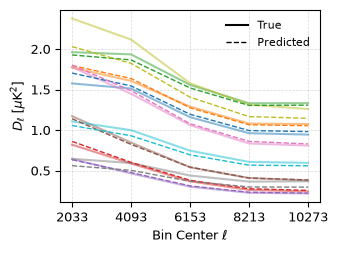

In [17]:
fig, ax = plt.subplots()

n_show = 10
rng = np.random.default_rng(42)
idx = rng.choice(true.shape[0], size=n_show, replace=False)

for i in idx:
    true_line, = ax.plot(
        ell_centers,
        true[i],
        alpha=0.5,
        linewidth=1.5,
    )

    ax.plot(
        ell_centers,
        pred_mean[i],
        color=true_line.get_color(),
        alpha=1.0,
        linewidth=1.0,
        linestyle="--",
        zorder=3
    )

ax.plot([], [], color='black', alpha=1.0, linewidth=1.5, label="True")
ax.plot([], [], color='black', alpha=1.0, linewidth=1.0, linestyle="--", label="Predicted")

ax.set_xlabel(r"Bin Center $\ell$")
ax.set_xticks(ell_centers)
ax.set_xticklabels(ax.set_xticklabels([f"{e:.0f}" for e in ell_centers]))
ax.set_ylabel(r"$D_\ell$ [$\mu \mathrm{K}^2$]")

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend(frameon=False, fontsize=8)

fig.savefig(FIG_DIR / f"many_heldout_true_predicted_spectra_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Stability Check

In [18]:
N_PILOT = 1000
TOL_MEAN, TOL_STD = 0.01, 0.05

torch.manual_seed(SEED)

_, _, samples_dl, _ = predict_mc(
    X[best_sim_global_idx],
    model,
    norms["X"].mean,
    norms["X"].std,
    normalize_X=True,
    n_mc_samples=N_PILOT,
    device=device,
)

cv = samples_dl.std(axis=0, ddof=1) / samples_dl.mean(axis=0)

n_mean = int(np.ceil((cv.max() / TOL_MEAN) ** 2))
n_std  = int(np.ceil(1 + 1 / (2 * TOL_STD ** 2)))

print(f"Per-bin CV: {np.round(cv, 3)}")
print(f"N for mean at {TOL_MEAN:.0%}: {n_mean}")
print(f"N for std  at {TOL_STD:.0%}: {n_std}")
print(f"N_MC = {max(n_mean, n_std)}")

Per-bin CV: [0.076 0.071 0.074 0.076 0.077]
N for mean at 1%: 60
N for std  at 5%: 201
N_MC = 201


## Save Handoff Files

In [19]:
heldout_metrics = {
    "heldout_mse": float(test_mse),
    "heldout_rmse": float(test_rmse),
    "heldout_mae": float(test_mae),
    "heldout_mean_percent_error": float(percent_err),
    "heldout_mean_predictive_std": [float(v) for v in heldout_pred_std.mean(axis=0)],
    "heldout_mean_predictive_std_overall": float(heldout_pred_std.mean()),
    "heldout_coverage_1sigma": float(phy_coverage_1sigma),
    "heldout_coverage_2sigma": float(phy_coverage_2sigma),
    "heldout_coverage_3sigma": float(phy_coverage_3sigma),
    "heldout_chi2": float(chi_squared),
    "heldout_dof": int(dof),
    "heldout_reduced_chi2": float(reduced_chi_squared),
    "heldout_mean_signed_z": float(np.mean(z_signed)),
    "heldout_z_percentiles": {
        "p50": float(np.percentile(z_score, 50)),
        "p68": float(np.percentile(z_score, 68)),
        "p90": float(np.percentile(z_score, 90)),
        "p95": float(np.percentile(z_score, 95)),
        "p99": float(np.percentile(z_score, 99)),
        "max": float(np.max(z_score)),
    },
    "best_sim_global_idx": int(best_sim_global_idx),
    "worst_sim_global_idx": int(worst_sim_global_idx),
    "n_mc_samples": int(N_MC_PLOT),
}

with HELDOUT_METRICS_PATH.open("w", encoding="utf-8") as fh:
    json.dump(heldout_metrics, fh, indent=4, sort_keys=True)
    fh.write("\n")

np.savez(
    HELDOUT_PREDICTIONS_PATH,
    pred_mean=pred_mean,
    pred_std=pred_std,
    true=true,
    heldout_indices=heldout_indices,
    ell=np.asarray(ell),
)

print(f"Held-Out Metrics:\n{HELDOUT_METRICS_PATH}")
print(f"Held-Out Predictions:\n{HELDOUT_PREDICTIONS_PATH}")

Held-Out Metrics:
/Users/robertxpearce/Desktop/Research/LEADS Lab/reionemu/reionemu-pasa-2026/results/pearce_2026_reionemu_mc_dropout/n_mc_201_epochs_1000_early_stop_150/records/heldout_metrics.json
Held-Out Predictions:
/Users/robertxpearce/Desktop/Research/LEADS Lab/reionemu/reionemu-pasa-2026/results/pearce_2026_reionemu_mc_dropout/n_mc_201_epochs_1000_early_stop_150/records/heldout_predictions.npz
